In [2]:
import mne
mne.set_log_level('error')

import numpy as np
import matplotlib.pyplot as plt
import glob

In [3]:
# Import raw data
glob.glob('Raw/Sub_1/Subject 1*')

['Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.json',
 'Raw/Sub_1\\Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf',
 'Raw/Sub_1\\Subject 1-ica.fif',
 'Raw/Sub_1\\Subject 1-raw.fif',
 'Raw/Sub_1\\Subject 1-raw_filt.fif',
 'Raw/Sub_1\\Subject 1-raw_ica.fif']

In [4]:
raw = mne.io.read_raw_edf('Raw/Sub_1/Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf',preload=True)

In [5]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
 chs: 127 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2025-01-25 15:18:28 UTC
 nchan: 127
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
>

In [6]:
raw.info['ch_names']

['TimestampS',
 'TimestampMs',
 'OrTimestampS',
 'OrTimestampMs',
 'Counter',
 'Interpolated',
 'Cz',
 'FCz',
 'Afz',
 'Fp1',
 'F5',
 'F1',
 'CP5',
 'CP3',
 'CP1',
 'P1',
 'P3',
 'P5',
 'P7',
 'PO7',
 'PO3',
 'O1',
 'Pz',
 'POz',
 'Oz',
 'O2',
 'PO4',
 'PO8',
 'P8',
 'P6',
 'P4',
 'P2',
 'CP2',
 'CP4',
 'CP6',
 'F2',
 'F6',
 'Fp2',
 'RawCq',
 'Battery',
 'BatteryPercent',
 'FwBufferSize',
 'FwClockTime',
 'MarkerHardware',
 'CQ.Cz',
 'CQ.FCz',
 'CQ.Afz',
 'CQ.Fp1',
 'CQ.F5',
 'CQ.F1',
 'CQ.CP5',
 'CQ.CP3',
 'CQ.CP1',
 'CQ.P1',
 'CQ.P3',
 'CQ.P5',
 'CQ.P7',
 'CQ.PO7',
 'CQ.PO3',
 'CQ.O1',
 'CQ.Pz',
 'CQ.POz',
 'CQ.Oz',
 'CQ.O2',
 'CQ.PO4',
 'CQ.PO8',
 'CQ.P8',
 'CQ.P6',
 'CQ.P4',
 'CQ.P2',
 'CQ.CP2',
 'CQ.CP4',
 'CQ.CP6',
 'CQ.F2',
 'CQ.F6',
 'CQ.Fp2',
 'CQ.Overall',
 'EQ.SampleRateQua',
 'EQ.OVERALL',
 'EQ.Cz',
 'EQ.FCz',
 'EQ.Afz',
 'EQ.Fp1',
 'EQ.F5',
 'EQ.F1',
 'EQ.CP5',
 'EQ.CP3',
 'EQ.CP1',
 'EQ.P1',
 'EQ.P3',
 'EQ.P5',
 'EQ.P7',
 'EQ.PO7',
 'EQ.PO3',
 'EQ.O1',
 'EQ.Pz',
 'EQ.POz'

In [7]:
raw.__dict__

{'_last_samps': array([76031]),
 '_first_samps': array([0]),
 'info': <Info | 8 non-empty values
  bads: []
  ch_names: TimestampS, TimestampMs, OrTimestampS, OrTimestampMs, Counter, ...
  chs: 127 EEG
  custom_ref_applied: False
  highpass: 0.0 Hz
  lowpass: 128.0 Hz
  meas_date: 2025-01-25 15:18:28 UTC
  nchan: 127
  projs: []
  sfreq: 256.0 Hz
  subject_info: <subject_info | his_id: X, sex: 0, last_name: X>
 >,
 'buffer_size_sec': 1.0,
 '_cals': array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 

In [8]:
# To set target channels
target_channels = [
    'Cz', 'FCz', 'Afz', 'Fp1', 'F5', 'F1', 'CP5', 'CP3', 'CP1', 'P1', 
    'P3', 'P5', 'P7', 'PO7', 'PO3', 'O1', 'Pz', 'POz', 'Oz', 'O2', 
    'PO4', 'PO8', 'P8', 'P6', 'P4', 'P2', 'CP2', 'CP4', 'CP6', 'F2', 
    'F6', 'Fp2'
]

raw.pick_channels(target_channels)

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [9]:
raw.plot(duration = 1);
plt.show()

In [10]:
# Rename channel to standard
raw.rename_channels({'Afz': 'AFz'})

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

In [11]:
raw.set_montage('standard_1020')

<RawEDF | Subject 1, Session 1, Block 1 Recording_FLEX2_213075_2025.01.25T15.18.28.08.00.md.edf, 32 x 76032 (297.0 s), ~18.6 MiB, data loaded>

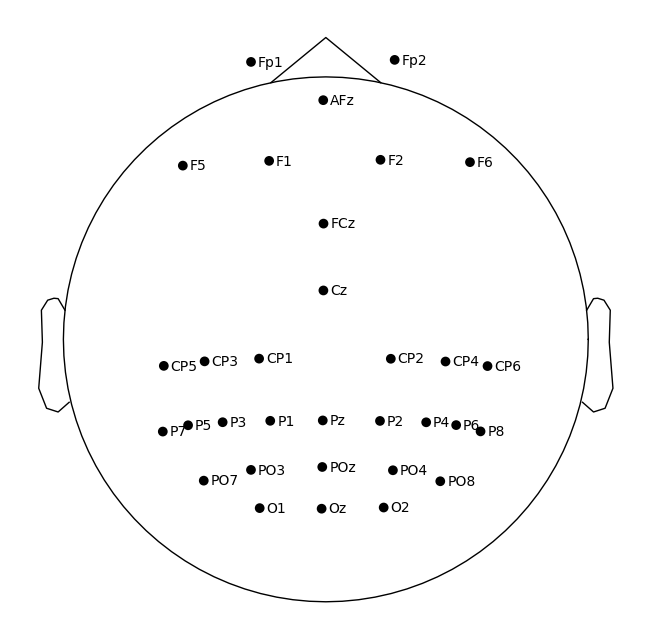

In [12]:
raw.plot_sensors(show_names=True);

In [13]:
mne.events_from_annotations(raw)

(array([[  116,     0,   569],
        [  172,     0,  1037],
        [  223,     0,   550],
        ...,
        [75592,     0,   784],
        [75644,     0,   662],
        [75991,     0,    18]], shape=(1071, 3)),
 {np.str_('behav,2,-1,103'): 1,
  np.str_('behav,2,-1,465'): 2,
  np.str_('behav,2,-1,801'): 3,
  np.str_('behav,2,-1,822'): 4,
  np.str_('behav,2,-1,885'): 5,
  np.str_('behav,2,-1,906'): 6,
  np.str_('behav,3,-1,1011'): 7,
  np.str_('behav,3,-1,1032'): 8,
  np.str_('behav,3,-1,1053'): 9,
  np.str_('behav,3,-1,124'): 10,
  np.str_('behav,3,-1,145'): 11,
  np.str_('behav,3,-1,166'): 12,
  np.str_('behav,3,-1,187'): 13,
  np.str_('behav,3,-1,208'): 14,
  np.str_('behav,3,-1,21'): 15,
  np.str_('behav,3,-1,229'): 16,
  np.str_('behav,3,-1,250'): 17,
  np.str_('behav,3,-1,271'): 18,
  np.str_('behav,3,-1,276'): 19,
  np.str_('behav,3,-1,297'): 20,
  np.str_('behav,3,-1,318'): 21,
  np.str_('behav,3,-1,339'): 22,
  np.str_('behav,3,-1,360'): 23,
  np.str_('behav,3,-1,381'): 2

c:\Users\Sam\anaconda3\envs\neural_data_science\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


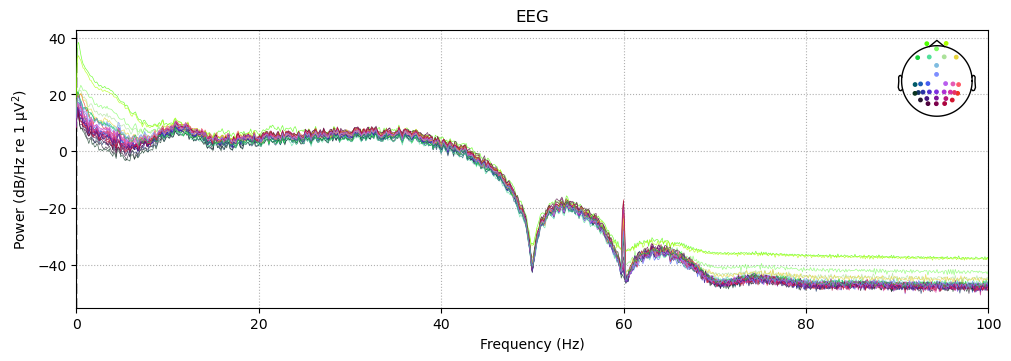

In [14]:
raw.plot_psd(fmax=100);

In [15]:
# set filter parameters
low_cut = 0.1
hi_cut = 40

raw_filt = raw.copy().filter(low_cut, hi_cut)

c:\Users\Sam\anaconda3\envs\neural_data_science\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


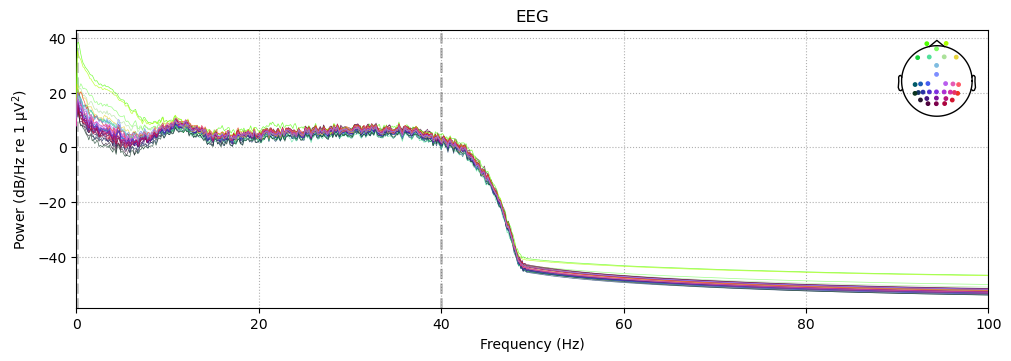

In [16]:
raw_filt.plot_psd(fmax=100);

In [17]:
raw_filt.plot(start=15, duration=5)

In [18]:
# save raw data
raw.save('Raw/Sub_1/Subject 1' + '-raw.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw.fif')]

In [19]:
# save filtered data
raw_filt.save('Raw/Sub_1/Subject 1' + '-raw_filt.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw_filt.fif')]

In [20]:
# begin Independent Component Analysis, 
# filter for ICA

ica_low_cut = 1.0
hi_cut = 30

raw_ica = raw.copy().filter(ica_low_cut, hi_cut)

In [21]:
# save ICA data
raw_ica.save('Raw/Sub_1/Subject 1' + '-raw_ica.fif',
            overwrite=True)

[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-raw_ica.fif')]

In [22]:
# Epoching for ICA
tstep = 1.0
events_ica = mne.make_fixed_length_events(raw_ica, duration=tstep)
epochs_ica = mne.Epochs(raw_ica, events_ica,
                        tmin=0.0, tmax=tstep,
                        baseline=None, preload=True)

In [23]:
# Set autoreject threshold

from autoreject import get_rejection_threshold

reject = get_rejection_threshold(epochs_ica);
print(reject)

Estimating rejection dictionary for eeg
{'eeg': np.float64(0.0002739529250544432)}


In [24]:
# Run ICA

random_state = 42
ica_n_components = .99

ica = mne.preprocessing.ICA(n_components=ica_n_components,
                            random_state=random_state,
                            )

ica.fit(epochs_ica,
        reject=reject,
        tstep=tstep)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,35 iterations on epochs (76072 samples)
ICA components,19
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,—


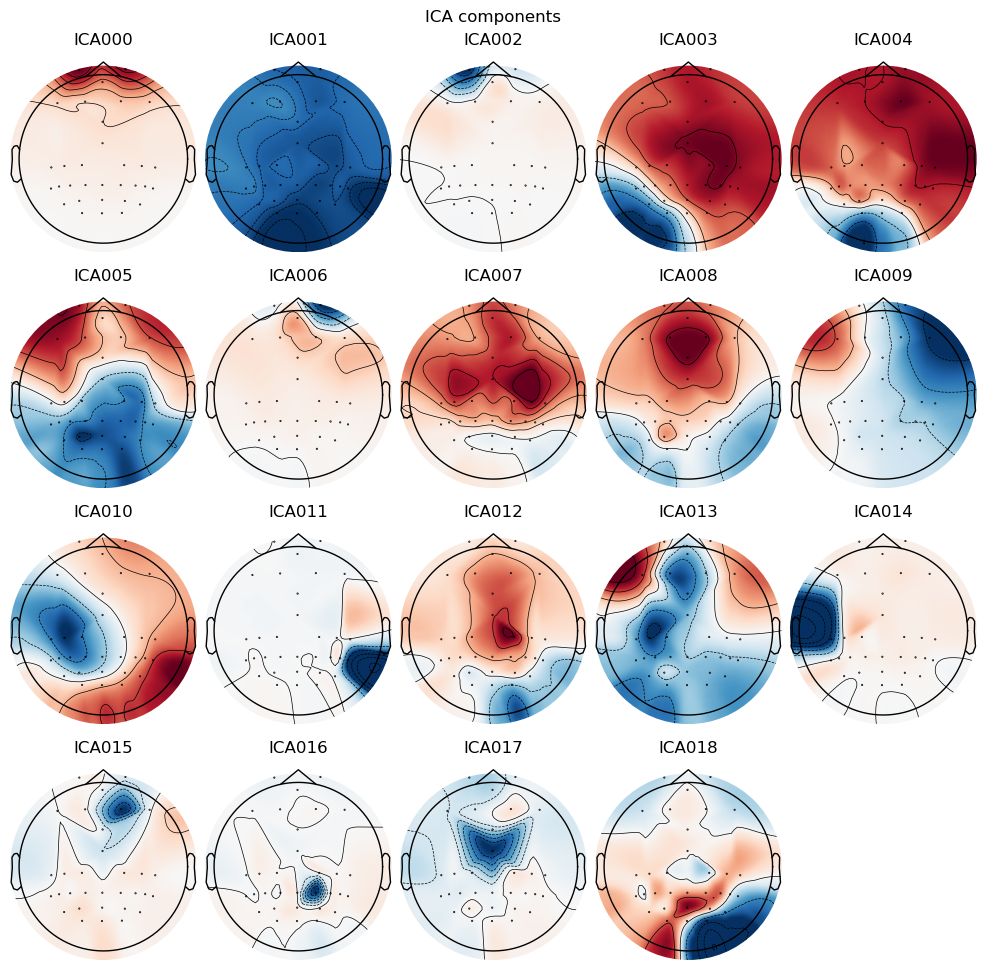

In [25]:
ica.plot_components();

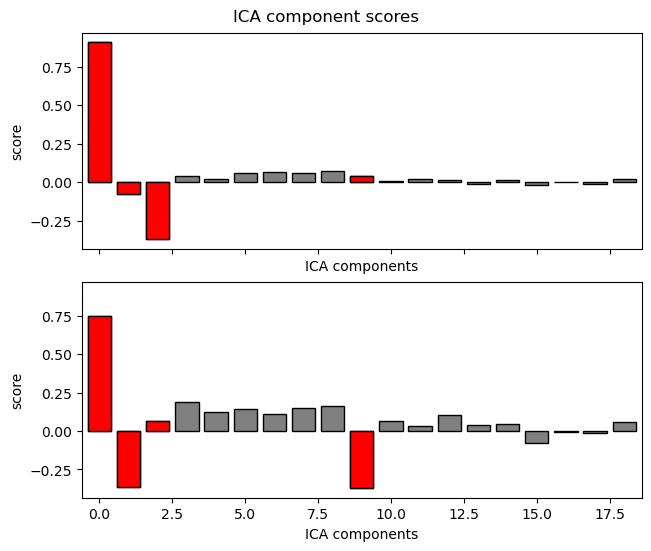

In [26]:
ica_z_thresh = 1.96
eog_indices, eog_scores = ica.find_bads_eog(raw_ica,
                                            ch_name=['Fp1', 'F6'],
                                            threshold=ica_z_thresh
                                            )

ica.exclude = eog_indices

ica.plot_scores(eog_scores);

In [27]:
# Save final ICA output
ica.save('Raw/Sub_1/Subject 1' + '-ica.fif',
            overwrite=True)

Method,fastica
Fit parameters,algorithm=parallelfun=logcoshfun_args=Nonemax_iter=1000
Fit,35 iterations on epochs (76072 samples)
ICA components,19
Available PCA components,32
Channel types,eeg
ICA components marked for exclusion,ICA000ICA009ICA002ICA001


In [28]:
# Pull event references for main Epoching

events, event_dict = mne.events_from_annotations(raw)

In [29]:
events

array([[  116,     0,   569],
       [  172,     0,  1037],
       [  223,     0,   550],
       ...,
       [75592,     0,   784],
       [75644,     0,   662],
       [75991,     0,    18]], shape=(1071, 3))

In [30]:
import pandas as pd

# pull metadata file i found in 'preprocessed' to fetch event codes
metadata = pd.read_parquet('experiment_metadata_categories.parquet')

print(metadata.head())
print("\nColumns:", metadata.columns.tolist())

    partition      fname category_name  category_num  category_img_num  \
0  stim_train  00000.jpg      aardvark             0                 0   
1  stim_train  00001.jpg      aardvark             0                 1   
2  stim_train  00002.jpg      aardvark             0                 2   
3  stim_train  00003.jpg      aardvark             0                 3   
4  stim_train  00004.jpg      aardvark             0                 4   

                                            filepath    dataset  \
0  /srv/eeg_reconstruction/shared/data/stimuli/re...  repr_eeg2   
1  /srv/eeg_reconstruction/shared/data/stimuli/re...  repr_eeg2   
2  /srv/eeg_reconstruction/shared/data/stimuli/re...  repr_eeg2   
3  /srv/eeg_reconstruction/shared/data/stimuli/re...  repr_eeg2   
4  /srv/eeg_reconstruction/shared/data/stimuli/re...  repr_eeg2   

  super_category minor_category  super_category_id  minor_category_id  
0        animals   Mammals_Land                  1                 41  
1       

In [ ]:
# 1. Extract the numeric event code from the filename ('00000.jpg' -> 0)
event_codes = metadata['fname'].str.replace('.jpg', '').astype(int)

# 2. Create a unique label for each image (e.g., 'aardvark/0')
event_names = metadata['category_name'] + '/' + event_codes.astype(str)

# 3. Zip them together into the final dictionary MNE needs
event_mapping = dict(zip(event_names, event_codes))

print(list(event_mapping.items())[:5])

[('aardvark/0', 0), ('aardvark/1', 1), ('aardvark/2', 2), ('aardvark/3', 3), ('aardvark/4', 4)]


In [32]:
events

array([[  116,     0,   569],
       [  172,     0,  1037],
       [  223,     0,   550],
       ...,
       [75592,     0,   784],
       [75644,     0,   662],
       [75991,     0,    18]], shape=(1071, 3))

In [33]:
# 1. Rebuild the names, forcing missing categories to say 'unknown'
event_names = metadata['category_name'].fillna('unknown').astype(str) + '/' + event_codes.astype(str)

# 2. Build the dictionary, strictly enforcing string keys and integer values
event_mapping = {str(k): int(v) for k, 
                 v in zip(event_names, event_codes)}

# 3. Filter down to ONLY the events present in your current data block
present_events = set(events[:, 2])
local_event_mapping = {name: code for name, 
                       code in event_mapping.items() if code in present_events}

In [35]:
tmin = -.200 
tmax = 1.00
baseline = (None, 0)

epochs = mne.Epochs(raw_filt,
                    events, local_event_mapping,
                    tmin, tmax,
                    baseline=baseline,
                    preload=True
                    )

In [37]:
epochs

<Epochs | 1070 events (all good), -0.199 – 1 s (baseline -0.199 – 0 s), ~80.5 MiB, data loaded,
 'aardvark/1': 1
 'aardvark/2': 1
 'aardvark/3': 1
 'aardvark/4': 1
 'aardvark/5': 1
 'aardvark/6': 1
 'aardvark/7': 1
 'aardvark/8': 1
 'aardvark/9': 1
 'abacus/10': 1
 and 1061 more events ...>

In [38]:
epochs[0]

<Epochs | 1 events (all good), -0.199 – 1 s (baseline -0.199 – 0 s), ~118 KiB, data loaded,
 'balloon/569': 1>

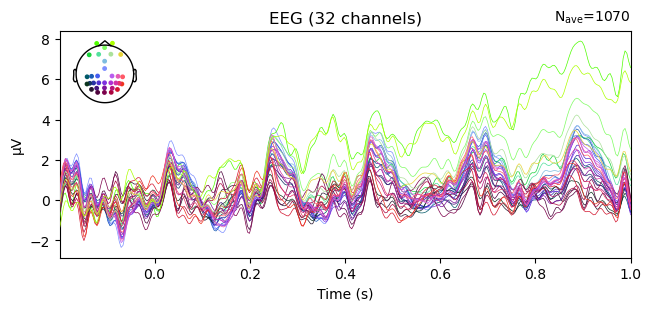

In [42]:
epochs.average().plot(spatial_colors=True);

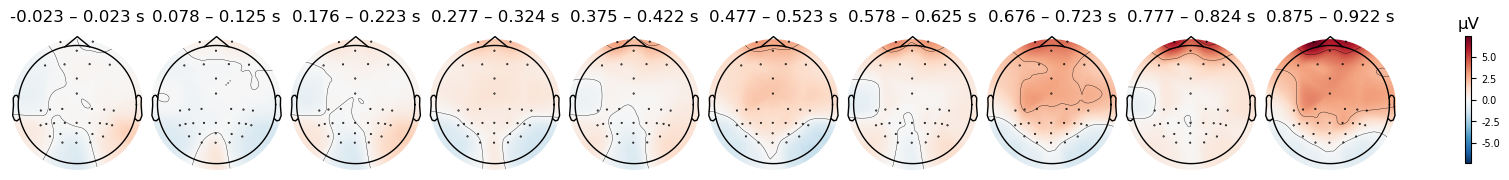

In [43]:
times = np.arange(0, tmax, 0.1)

epochs.average().plot_topomap(times=times, average=0.050);

In [45]:
ica = mne.preprocessing.read_ica('Raw\Sub_1\Subject 1-ica.fif')

epochs_postica = ica.apply(epochs.copy())

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Sam\AppData\Local\Temp\ipykernel_4980\1723227577.py:1: SyntaxWarning: invalid escape sequence '\S'
  ica = mne.preprocessing.read_ica('Raw\Sub_1\Subject 1-ica.fif')


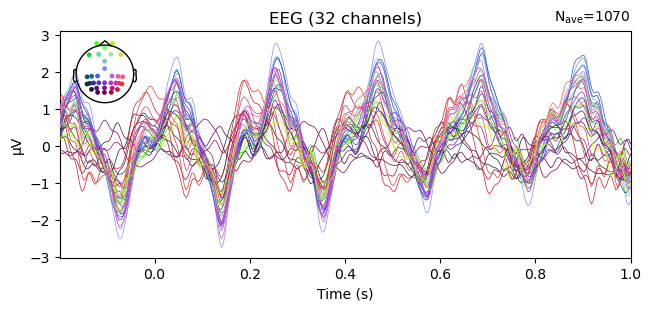

In [46]:
epochs_postica.average().plot(spatial_colors=True);

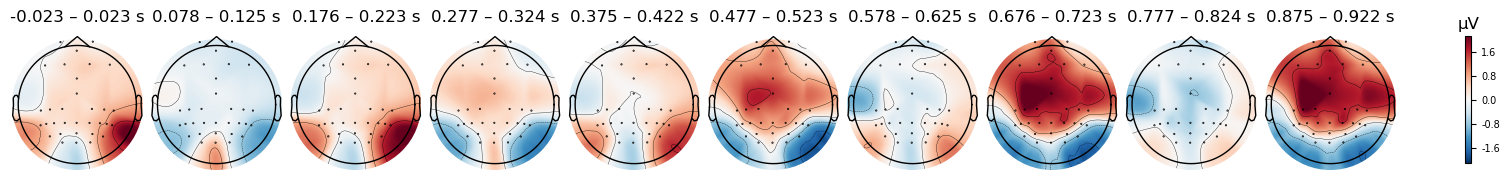

In [47]:
times = np.arange(0, tmax, 0.1)

epochs_postica.average().plot_topomap(times=times, average=0.050);

In [48]:
# Save the cleaned, filtered epochs

epochs_postica.save('Raw\Sub_1\Subject 1' + '-ep_post_ica.fif', overwrite=True)


<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Sam\AppData\Local\Temp\ipykernel_4980\4290943630.py:3: SyntaxWarning: invalid escape sequence '\S'
  epochs_postica.save('Raw\Sub_1\Subject 1' + '-ep_post_ica.fif', overwrite=True)


[WindowsPath('c:/Users/Sam/Documents/GitHub/Alljoined_prepro/Raw/Sub_1/Subject 1-ep_post_ica.fif')]

In [51]:
# and to save this to ml readabl np arrays
# first, convert the brainwaves into the X array
x = epochs_postica.get_data(copy=False) 

# convert the mapped image IDs into the Y array
y = epochs_postica.events[:, 2]

print(f"Brainwaves (x) shape: {x.shape}")
print(f"Labels (y) shape: {y.shape}")

Brainwaves (x) shape: (1070, 32, 308)
Labels (y) shape: (1070,)


In [53]:
# To save these
np.save('Raw\Sub_1\Subject 1' + 'block1_x.npy', x)
np.save('Raw\Sub_1\Subject 1' + 'block1_y.npy', y)

<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
<>:2: SyntaxWarning: invalid escape sequence '\S'
<>:3: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Sam\AppData\Local\Temp\ipykernel_4980\1186363368.py:2: SyntaxWarning: invalid escape sequence '\S'
  np.save('Raw\Sub_1\Subject 1' + 'block1_x.npy', x)
C:\Users\Sam\AppData\Local\Temp\ipykernel_4980\1186363368.py:3: SyntaxWarning: invalid escape sequence '\S'
  np.save('Raw\Sub_1\Subject 1' + 'block1_y.npy', y)
